### Part A: Data Loading and Preparation

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


#### Normalize pixel values and explore dataset statistics

In [2]:
# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"Min pixel value (train): {np.min(x_train_normalized)}")
print(f"Max pixel value (train): {np.max(x_train_normalized)}")
print(f"Min pixel value (test): {np.min(x_test_normalized)}")
print(f"Max pixel value (test): {np.max(x_test_normalized)}")

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nDistribution of training labels:")
for i, count in enumerate(np.bincount(y_train)):
    print(f"  {class_names[i]}: {count}")

Min pixel value (train): 0.0
Max pixel value (train): 1.0
Min pixel value (test): 0.0
Max pixel value (test): 1.0

Distribution of training labels:
  T-shirt/top: 6000
  Trouser: 6000
  Pullover: 6000
  Dress: 6000
  Coat: 6000
  Sandal: 6000
  Shirt: 6000
  Sneaker: 6000
  Bag: 6000
  Ankle boot: 6000


#### Visualize sample images

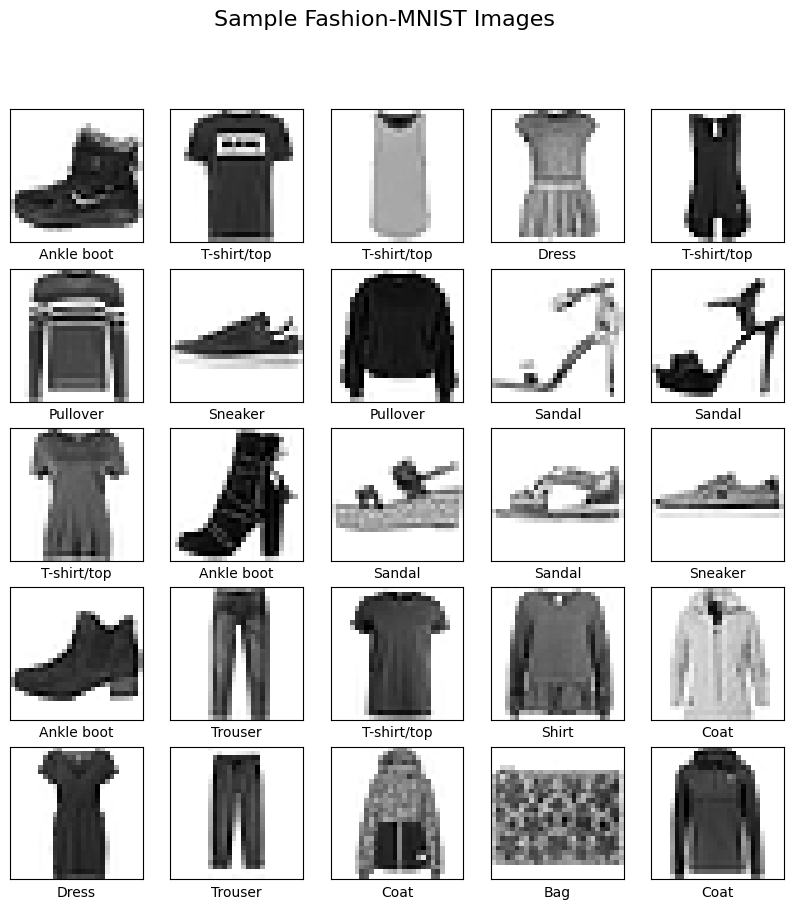

In [3]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle('Sample Fashion-MNIST Images', fontsize=16)
plt.show()

### Part B: PCA Implementation

#### Reshape data for PCA and apply PCA to reduce to 2D

In [4]:
# Reshape images from 28x28 to 784-dimensional vectors
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
x_test_flat = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

print(f"x_train_flat shape: {x_train_flat.shape}")
print(f"x_test_flat shape: {x_test_flat.shape}")

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

print(f"x_train_pca shape: {x_train_pca.shape}")
print(f"x_test_pca shape: {x_test_pca.shape}")

x_train_flat shape: (60000, 784)
x_test_flat shape: (10000, 784)
x_train_pca shape: (60000, 2)
x_test_pca shape: (10000, 2)


#### Plot explained variance ratio

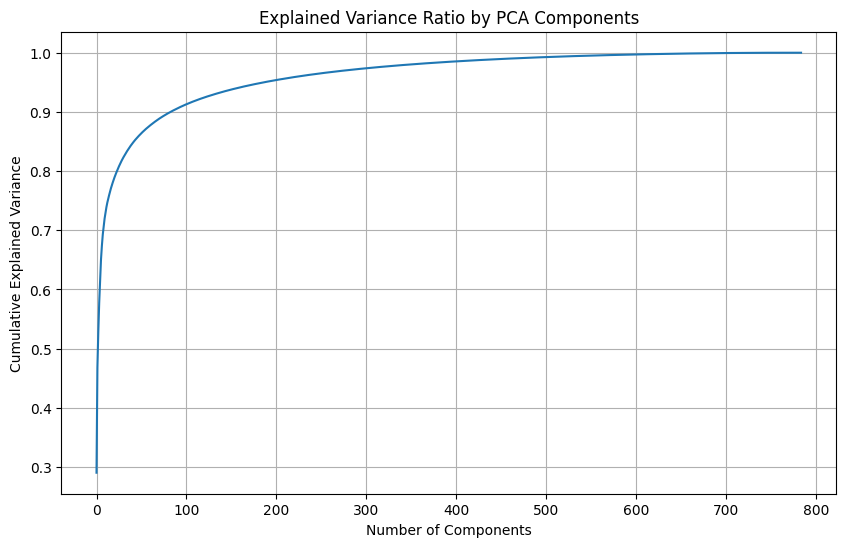

Explained variance ratio for 2 components: 0.4679


In [5]:
pca_full = PCA(n_components=784) # Fit PCA with all components to get explained variance ratio
pca_full.fit(x_train_flat)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio by PCA Components')
plt.grid(True)
plt.show()

print(f"Explained variance ratio for 2 components: {pca.explained_variance_ratio_.sum():.4f}")

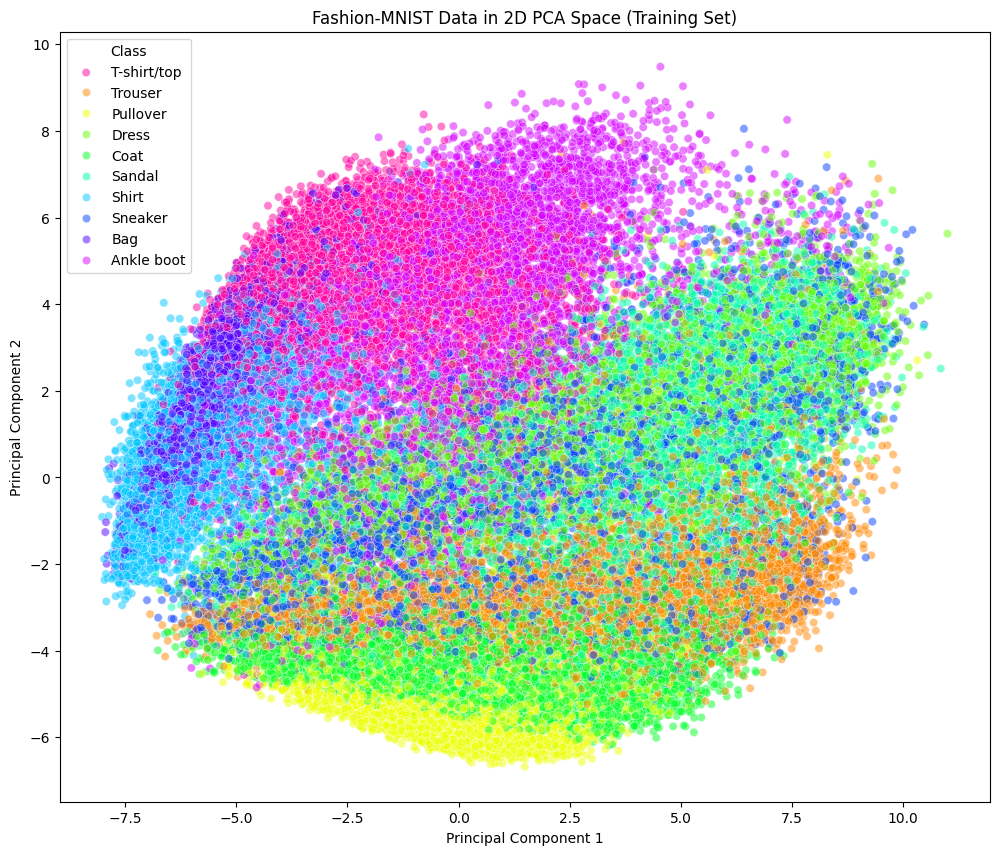


Analysis of cluster separation:
In the PCA plot, we can observe some separation between certain classes (e.g., 'Ankle boot' and 'Sandal' tend to form distinct clusters). However, many classes, especially those visually similar like 'T-shirt/top', 'Shirt', 'Pullover', 'Coat', and 'Dress', significantly overlap. This indicates that a linear dimensionality reduction technique like PCA might not be sufficient to clearly separate all classes based on just two principal components. PCA aims to preserve variance, not necessarily class separation.


In [6]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=x_train_pca[:, 0],
    y=x_train_pca[:, 1],
    hue=y_train,
    palette=sns.color_palette("hsv", 10),
    legend='full',
    alpha=0.5
)
plt.title('Fashion-MNIST Data in 2D PCA Space (Training Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class', labels=class_names, loc='best')
plt.show()

print("\nAnalysis of cluster separation:")
print("In the PCA plot, we can observe some separation between certain classes (e.g., 'Ankle boot' and 'Sandal' tend to form distinct clusters). However, many classes, especially those visually similar like 'T-shirt/top', 'Shirt', 'Pullover', 'Coat', and 'Dress', significantly overlap. This indicates that a linear dimensionality reduction technique like PCA might not be sufficient to clearly separate all classes based on just two principal components. PCA aims to preserve variance, not necessarily class separation.")

### Part D: Comparison and Analysis

#### Comparison of Computation Time

In [9]:
import time

# Time PCA on the full training dataset
start_time_pca = time.time()
pca_full_data = PCA(n_components=2)
x_train_pca_time = pca_full_data.fit_transform(x_train_flat)
end_time_pca = time.time()
pca_time = end_time_pca - start_time_pca

print(f"PCA computation time (full dataset, {x_train_flat.shape[0]} samples): {pca_time:.4f} seconds")

# Time t-SNE on the subset (using the previously defined x_subset_flat)
start_time_tsne = time.time()
tsne_time_obj = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
x_train_tsne_time = tsne_time_obj.fit_transform(x_subset_flat)
end_time_tsne = time.time()
tsne_time = end_time_tsne - start_time_tsne

print(f"t-SNE computation time (subset, {x_subset_flat.shape[0]} samples): {tsne_time:.4f} seconds")

print("\nNote: PCA was timed on the full 60,000 samples, while t-SNE was timed on a subset of 10,000 samples due to its higher computational cost. Even with fewer samples, t-SNE typically takes significantly longer.")

PCA computation time (full dataset, 60000 samples): 0.9829 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE computation time (subset, 10000 samples): 132.3815 seconds

Note: PCA was timed on the full 60,000 samples, while t-SNE was timed on a subset of 10,000 samples due to its higher computational cost. Even with fewer samples, t-SNE typically takes significantly longer.


In [7]:
# For computational efficiency, let's use a subset of the training data
# Using the full dataset (60,000 points) can be very slow for t-SNE
n_samples = 10000 # Using 10,000 samples for demonstration

# Randomly select a subset of indices
np.random.seed(42) # for reproducibility
subset_indices = np.random.choice(x_train_flat.shape[0], n_samples, replace=False)

x_subset_flat = x_train_flat[subset_indices]
y_subset = y_train[subset_indices]

print(f"Subset shape for t-SNE: {x_subset_flat.shape}")

# Apply t-SNE to reduce to 2D
# Experiment with different perplexity values (e.g., 5, 30, 50)
# n_iter_without_progress increases robustness but takes longer

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1) # Using 30 as a starting point
x_train_tsne = tsne.fit_transform(x_subset_flat)

print(f"x_train_tsne shape: {x_train_tsne.shape}")

Subset shape for t-SNE: (10000, 784)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


x_train_tsne shape: (10000, 2)


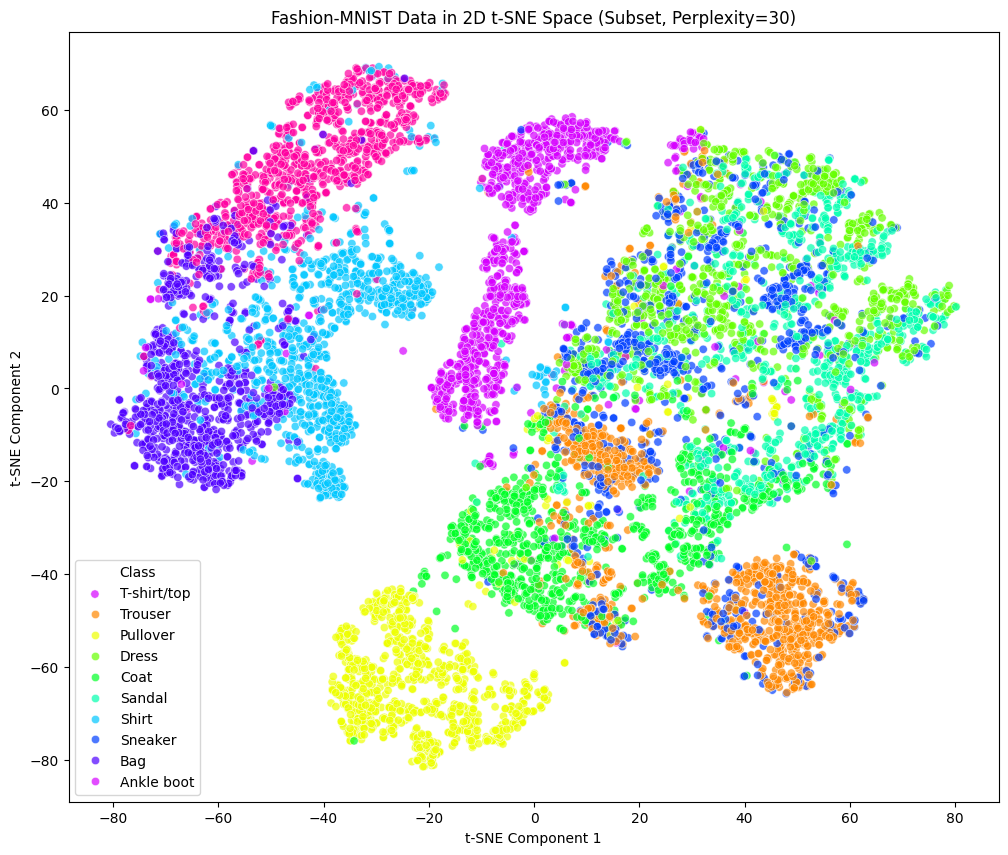

In [8]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=x_train_tsne[:, 0],
    y=x_train_tsne[:, 1],
    hue=y_subset,
    palette=sns.color_palette("hsv", 10),
    legend='full',
    alpha=0.7
)
plt.title(f'Fashion-MNIST Data in 2D t-SNE Space (Subset, Perplexity=30)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Class', labels=class_names, loc='best')
plt.show()

### Part E: UMAP Implementation

In [10]:
# Install UMAP (if not already installed)
!pip install umap-learn

### Part F: Autoencoders for Dimensionality Reduction

In [13]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Define the input shape (same as our flattened images)
input_dim = x_train_flat.shape[1] # 784 for Fashion-MNIST
encoding_dim = 2 # Reduce to 2 dimensions for visualization

# Encoder architecture
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoder_output = Dense(encoding_dim, activation='linear')(encoded) # Linear activation for the latent space

# Decoder architecture
decoded = Dense(64, activation='relu')(encoder_output)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded) # Sigmoid for pixel values between 0 and 1

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model (to get the 2D representation)
encoder = Model(input_img, encoder_output)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

print("Autoencoder Summary:")
autoencoder.summary()
print("\nEncoder Summary:")
encoder.summary()

# Train the autoencoder on the normalized flattened training data
# Using the same subset as t-SNE and UMAP for consistency in comparison
print(f"\nTraining Autoencoder on {x_subset_flat.shape[0]} samples...")
history = autoencoder.fit(x_subset_flat, x_subset_flat,
                          epochs=50, # You might want to adjust this
                          batch_size=256,
                          shuffle=True,
                          validation_split=0.1,
                          verbose=0) # Set verbose=1 to see training progress

print("Training complete.")

# Get the 2D latent space representation
x_train_autoencoder_2d = encoder.predict(x_subset_flat)

print(f"x_train_autoencoder_2d shape: {x_train_autoencoder_2d.shape}")

Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,514 (853.57 KB)

 Trainable params: 218,514 (853.57 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)


Training Autoencoder on 10000 samples...
Training complete.
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
x_train_autoencoder_2d shape: (10000, 2)


#### Visualize data in 2D Autoencoder Latent Space, colored by class labels

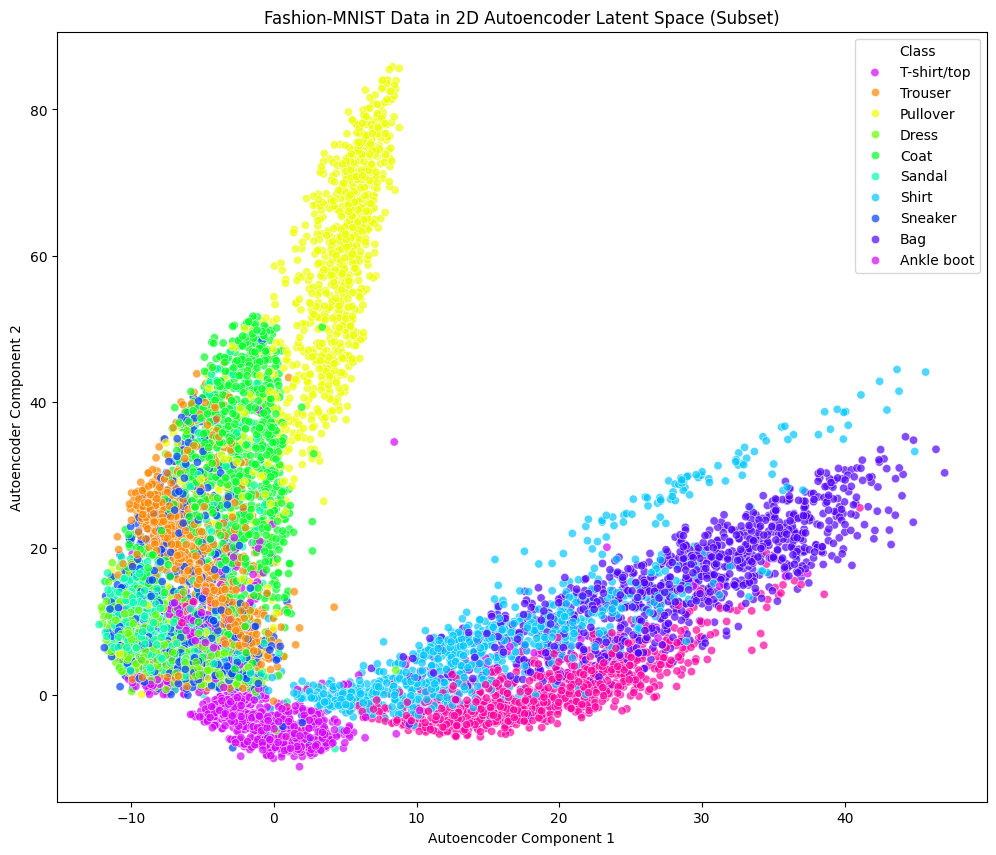

In [14]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=x_train_autoencoder_2d[:, 0],
    y=x_train_autoencoder_2d[:, 1],
    hue=y_subset,
    palette=sns.color_palette("hsv", 10),
    legend='full',
    alpha=0.7
)
plt.title(f'Fashion-MNIST Data in 2D Autoencoder Latent Space (Subset)')
plt.xlabel('Autoencoder Component 1')
plt.ylabel('Autoencoder Component 2')
plt.legend(title='Class', labels=class_names, loc='best')
plt.show()

In [11]:
import umap

# Apply UMAP to the same data subset used for t-SNE
# Using default parameters for n_neighbors and min_dist as a starting point
# (n_neighbors=15, min_dist=0.1 are common defaults)
umap_reducer = umap.UMAP(n_components=2, random_state=42)
x_train_umap = umap_reducer.fit_transform(x_subset_flat)

print(f"x_train_umap shape: {x_train_umap.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


x_train_umap shape: (10000, 2)


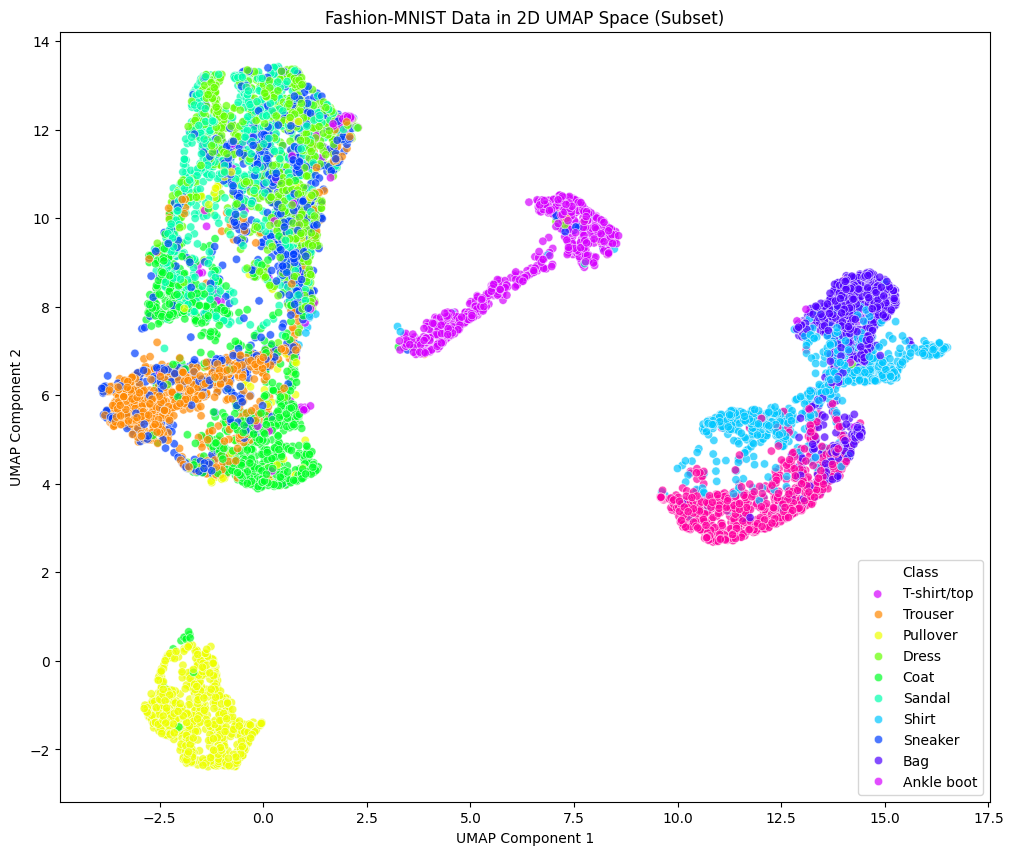

In [12]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=x_train_umap[:, 0],
    y=x_train_umap[:, 1],
    hue=y_subset,
    palette=sns.color_palette("hsv", 10),
    legend='full',
    alpha=0.7
)
plt.title(f'Fashion-MNIST Data in 2D UMAP Space (Subset)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(title='Class', labels=class_names, loc='best')
plt.show()